1. Librerías y carga de datos

Cargamos las librerías que usaremos en todo el trabajo y leemos el conjunto de datos.



In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import gzip
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
CARPETA = "/content/drive/MyDrive/TFM"   # donde se guardará todo
SEMILLA = 42
np.random.seed(SEMILLA) #Fijada para garantizar la reproducibilidad de los resultados


In [3]:
RUTA = "/content/drive/MyDrive/TFM/train.jsonl.gz"
with gzip.open(RUTA, "rt", encoding="utf-8") as f:
  df = pd.DataFrame(json.loads(linea) for linea in f)

print(f"Reseñas cargadas: {len(df):,}")
print(f"Columnas disponibles: {list(df.columns)}")
# Mostramos las primeras filas para entender la estructura de los datos
df[["stars", "product_category", "review_title", "review_body"]].head()

Reseñas cargadas: 200,000
Columnas disponibles: ['review_id', 'product_id', 'reviewer_id', 'stars', 'review_body', 'review_title', 'language', 'product_category']


,stars,product_category,review_title,review_body
0,1,electronics,television Nevir,Nada bueno se me fue ka pantalla en menos de 8...
1,1,electronics,Dinero tirado a la basura con esta compra,"Horrible, nos tuvimos que comprar otro porque ..."
2,1,drugstore,solo llega una unidad cuando te obligan a comp...,Te obligan a comprar dos unidades y te llega s...
3,1,wireless,PRODUCTO NO RECIBIDO.,"No entro en descalificar al vendedor, solo pue..."
4,1,shoes,Devuelto,Llega tarde y co la talla equivocada


Qué contiene cada columna que nos interesa.

In [4]:
resumen = pd.DataFrame({
    "Tipo": df.dtypes.astype(str),
    "Valores nulos": df.isna().sum(),
    "Valores únicos": df.nunique(),
    "Ejemplo": [str(df[c].iloc[0])[:60] for c in df.columns],
})
resumen

,Tipo,Valores nulos,Valores únicos,Ejemplo
review_id,object,0,200000,es_0491108
product_id,object,0,150938,product_es_0296024
reviewer_id,object,0,179076,reviewer_es_0999081
stars,int64,0,5,1
review_body,object,0,198264,Nada bueno se me fue ka pantalla en menos de 8...
review_title,object,0,112114,television Nevir
language,object,0,1,es
product_category,object,0,30,electronics


2. Análisis exploratorio EDA

In [5]:
print("Reseñas por número de estrellas:")
print(df["stars"].value_counts().sort_index())

Reseñas por número de estrellas:
stars
1    40000
2    40000
3    40000
4    40000
5    40000
Name: count, dtype: int64


In [6]:
# Cantidad de reseñas por industria.
print(f"\nNúmero de industrias distintas: {df['product_category'].nunique()}")
print("\nIndustrias con más reseñas:")
print(df["product_category"].value_counts().head(30))


Número de industrias distintas: 30

Industrias con más reseñas:
product_category
home                        26962
wireless                    25886
toy                         13647
sports                      13189
pc                          11191
home_improvement            10879
electronics                 10385
beauty                       7337
automotive                   7143
kitchen                      6695
apparel                      5737
drugstore                    5513
book                         5264
furniture                    5229
baby_product                 4881
office_product               4771
lawn_and_garden              4237
other                        3937
pet_products                 3713
personal_care_appliances     3573
luggage                      3328
camera                       3029
shoes                        2754
digital_ebook_purchase       1843
video_games                  1733
jewelry                      1598
musical_instruments          1530


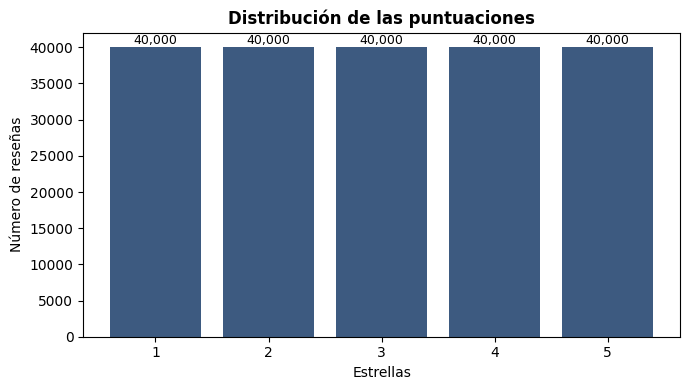

In [7]:
#Gráfico 1: distribución de puntuaciones

conteo = df["stars"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(conteo.index, conteo.values, color="#3d5a80")
ax.set_xlabel("Estrellas")
ax.set_ylabel("Número de reseñas")
ax.set_title("Distribución de las puntuaciones", weight="bold") # Etiquetamos cada barra con su valor para que se lea sin mirar el eje
for x, y in zip(conteo.index, conteo.values):
  ax.text(x, y, f"{y:,}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

Tenemos 40000 reseñas por cada puntaje de estrellas possibles, lo que quiere decir que el conjunto de datos está equilibrado.

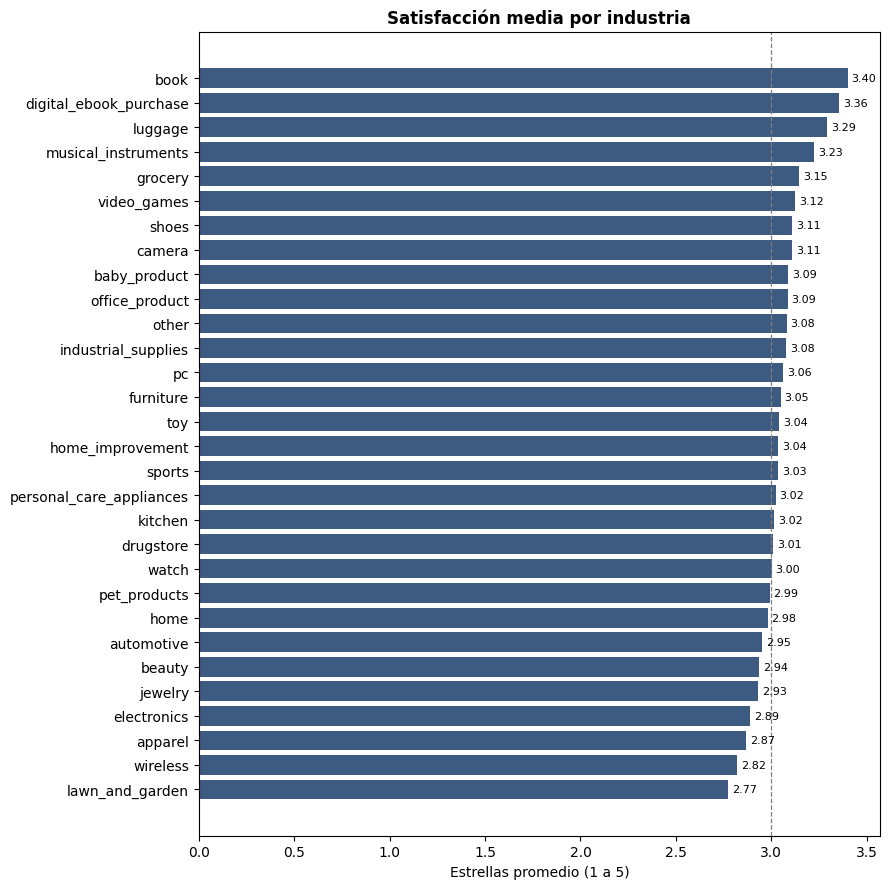

In [8]:
#Gráfico 2: satisfacción media por industria

media = df.groupby("product_category")["stars"].mean().sort_values()
fig, ax = plt.subplots(figsize=(9, 9))
ax.barh(media.index, media.values, color="#3d5a80")
media_global = df["stars"].mean()
ax.axvline(media_global, color="gray", ls="--", lw=0.9, #Identificamos la media global, con una linea
  label=f"Media globarl ({media_global:.2f})")

ax.set_xlabel("Estrellas promedio (1 a 5)")
ax.set_title("Satisfacción media por industria", weight="bold")
for i, v in enumerate(media.values):
  ax.text(v + 0.02, i, f"{v:.2f}", va="center", fontsize=8)
plt.tight_layout()
plt.show()

3. Limpieza de datos. Verificación de la calidad de los datos



In [9]:
filas_iniciales = len(df)
df = df.dropna(subset=["review_body"])
df = df[df["review_body"].str.strip().str.len() >= 3]
df = df.drop_duplicates(subset=["review_id"])
df = df.reset_index(drop=True)

print(f"Reseñas antes de limpiar : {filas_iniciales:,}")
print(f"Reseñas después de limpiar: {len(df):,}")
print(f"Eliminadas : {filas_iniciales - len(df):,}")
print("\nValores nulos por columna tras la limpieza:")
print(df.isna().sum())

Reseñas antes de limpiar : 200,000
Reseñas después de limpiar: 200,000
Eliminadas : 0

Valores nulos por columna tras la limpieza:
review_id           0
product_id          0
reviewer_id         0
stars               0
review_body         0
review_title        0
language            0
product_category    0
dtype: int64


In [10]:
# ¿Las reseñas muy cortas aportan información o son ruido?
# Si su distribución de estrellas fuera plana (igual en todas), serían ruido.
# Si está concentrada en los extremos, son MUY informativas y hay que conservarlas.
n_palabras = df["review_body"].str.split().str.len()
cortas = df[n_palabras <= 2]

print(f"Reseñas de 1-2 palabras: {len(cortas):,} ({len(cortas)/len(df):.2%} del total)\n")
print("Distribución de estrellas en esas reseñas cortas:")
print(cortas["stars"].value_counts(normalize=True).sort_index().round(3))
print("\nDistribución en el conjunto completo (para comparar):")
print(df["stars"].value_counts(normalize=True).sort_index().round(3))
print("\nEjemplos de reseñas cortas (muestra aleatoria, con su puntuación):")
for _, fila in cortas.sample(10, random_state=SEMILLA).iterrows():
    print(f"  · [{fila['stars']}★] {fila['review_body']}")

Reseñas de 1-2 palabras: 111 (0.06% del total)

Distribución de estrellas en esas reseñas cortas:
stars
1    0.027
2    0.054
3    0.171
4    0.315
5    0.432
Name: proportion, dtype: float64

Distribución en el conjunto completo (para comparar):
stars
1    0.2
2    0.2
3    0.2
4    0.2
5    0.2
Name: proportion, dtype: float64

Ejemplos de reseñas cortas (muestra aleatoria, con su puntuación):
  · [5★] Excelente producto!!
  · [3★] Relación calidad-precio
  · [2★] Difícil programación
  · [5★] Encaja perfectamente
  · [5★] PRODUCTO RECOMENDADO
  · [5★] Buena calidad/precio
  · [4★] Entretenimiento asegurado
  · [4★] calidad-precio buena
  · [5★] Buena calidad-precio
  · [3★] Buena calidad-precio


4. Preparación del texto

In [11]:
#Construcción del texto y de la variable objetivo
# Unimos título + cuerpo y pasamos todo a minúsculas para que el modelo no distinga entre "Bueno" y "bueno" (serían dos palabras distintas si no lo hacemos).
df["texto"] = (df["review_title"].fillna("") + " " + df["review_body"].fillna("")).str.lower()

# Variable objetivo (lo que el modelo debe predecir): 1 = cliente satisfecho
df["feliz"] = (df["stars"] >= 4).astype(int)

print(f"Proporción de clientes satisfechos: {df['feliz'].mean():.1%}")
print(f"Longitud media de una reseña      : {df['texto'].str.len().mean():.0f} caracteres")

# Ejemplo de cómo queda una fila ya preparada
df[["stars", "feliz", "texto"]].head(3)

Proporción de clientes satisfechos: 40.0%
Longitud media de una reseña      : 171 caracteres


,stars,feliz,texto
0,1,0,television nevir nada bueno se me fue ka panta...
1,1,0,dinero tirado a la basura con esta compra horr...
2,1,0,solo llega una unidad cuando te obligan a comp...


5. Análisis de aspectos por industria

In [12]:
# Diccionario de aspectos
# Cada aspecto se detecta buscando fragmentos de palabra en el texto.
# Usamos raíces (ej. "barat" detecta barato/barata/baratos) para captar variantes.
ASPECTOS = {
    "Precio":           [r"\bprecio", r"\bbarat", r"\bcaro", r"\bcarísim", r"\beconómic", r"vale la pena"],
    "Calidad":          [r"\bcalidad", r"\bdefectuos", r"\bacabado", r"\bmaterial", r"\bfrágil"],
    "Durabilidad":      [r"\bduradero", r"\bduración", r"\bdura mucho", r"\bdura poco", r"\brompe", r"\broto", r"\baguanta", r"\bresistente"],
    "Envío/Entrega":    [r"\benvío", r"\bentrega", r"\bllegó", r"\btardó", r"\bdemora", r"\bretras"],
    "Servicio":         [r"\bservicio", r"\batención", r"\bvendedor", r"\breembolso", r"\bdevoluci", r"\bgarantía"],
    "Facilidad de uso": [r"\bfácil", r"\bsencill", r"\bcómod", r"\bpráctic", r"\bintuitiv", r"difícil de"],
    "Diseño":           [r"\bdiseño", r"\bbonit", r"\belegante", r"\bpreciosa", r"\bprecioso", r"\bfeo\b", r"\bestétic"],
    "Tamaño/Talla":     [r"\btalla", r"\btamaño", r"\bgrande", r"\bpequeñ", r"\bajuste", r"\bmedida"],
}

def analizar_industria(resenas, minimo_menciones=30):
    resultado = {}
    for aspecto, palabras in ASPECTOS.items():
      patron = "|".join(palabras)
      menciona = resenas ["texto"].str.contains (patron, regex=True, na=False)
      if menciona.sum()>= minimo_menciones:
        resultado[aspecto] = round(resenas.loc[menciona, "feliz"].mean()*100, 1)
    return resultado
print("Función definida, Aspectos analizado:", list(ASPECTOS.keys()))


Función definida, Aspectos analizado: ['Precio', 'Calidad', 'Durabilidad', 'Envío/Entrega', 'Servicio', 'Facilidad de uso', 'Diseño', 'Tamaño/Talla']


In [13]:
#COMPROBACIÓN
for aspecto, palabras in ASPECTOS.items():
  patron = "|".join(palabras)
  menciona = df["texto"].str.contains(patron, regex=True, na=False)
  print(f"\n {aspecto}: {menciona.sum():,} reseñas lo mencionan")
  for t in df.loc[menciona, "texto"].sample(2, random_state=SEMILLA):
    print(f"· {t[:100]} ")


 Precio: 34,297 reseñas lo mencionan
· insuficiente lo compré para usar en un baño dónde tenía mucha condensación, aunque estuviese encendi 
· calidad-precio muy buen producto, edtoy muy contenta con la compra! 

 Calidad: 45,854 reseñas lo mencionan
· defectuoso me ha llegado defectuoso me sabe a quemado tengo 2 años en el mundo del vapeo y este me h 
· buen producto. buen protector, totalmente transparente, cristal de calidad seguro. trasmite buena se 

 Durabilidad: 13,528 reseñas lo mencionan
· buen servicio técnico. aunque el ordenador esta bien para un uso domestico. su carcasa no aguanta el 
· bastante 👎 los brazos de la muñeca se rompen y se les quita el color en menos de 24 horas. muy mal a 

 Envío/Entrega: 15,790 reseñas lo mencionan
· relación calidad / precio correcta el producto llegó bien embalado. al imprimir en blanco y negro la 
· la entrega urgente deja mucho que desear doy una estrella por la respuesta rápida del vendedor. esto 

 Servicio: 10,783 reseñas lo mencio

In [14]:
# Aplicamos la MISMA función a varias industrias
# Esto demuestra la reutilización: un solo código, muchas industrias.
INDUSTRIAS = {
    "automotive":  "Automotriz",
    "beauty":      "Belleza",
    "toy":         "Juguetes",
    "book":        "Libros",
    "electronics": "Electrónica",
}

tabla = {}
for clave, nombre in INDUSTRIAS.items():
    subconjunto = df[df["product_category"] == clave]
    tabla[nombre] = analizar_industria(subconjunto)
    print(f"{nombre:<14} analizada ({len(subconjunto):,} reseñas)")

# Convertimos el resultado en una tabla: filas = aspectos, columnas = industrias
T = pd.DataFrame(tabla)
print("\n% de clientes satisfechos entre quienes mencionan cada aspecto:")
T

Automotriz     analizada (7,143 reseñas)
Belleza        analizada (7,337 reseñas)
Juguetes       analizada (13,647 reseñas)
Libros         analizada (5,264 reseñas)
Electrónica    analizada (10,385 reseñas)

% de clientes satisfechos entre quienes mencionan cada aspecto:


,Automotriz,Belleza,Juguetes,Libros,Electrónica
Precio,54.6,52.1,45.2,56.5,54.8
Calidad,44.4,53.0,41.3,52.0,47.7
Durabilidad,29.4,35.4,30.1,30.8,34.4
Envío/Entrega,39.9,36.9,36.7,49.5,38.8
Servicio,23.8,18.7,20.9,32.8,21.7
Facilidad de uso,65.0,60.3,54.7,64.1,58.8
Diseño,45.1,57.4,54.4,63.2,51.3
Tamaño/Talla,37.8,42.7,37.8,44.4,44.5


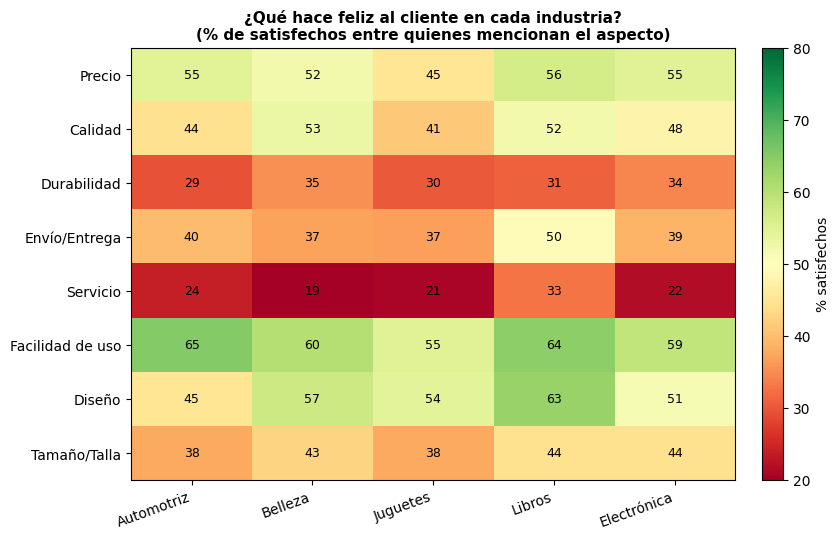

Aspecto con mayor asociación a la satisfacción, por industria:
  Automotriz     → Facilidad de uso (65%)
  Belleza        → Facilidad de uso (60%)
  Juguetes       → Facilidad de uso (55%)
  Libros         → Facilidad de uso (64%)
  Electrónica    → Facilidad de uso (59%)


In [15]:
# Gráfico 3: mapa de calor comparativo
# Un mapa de calor permite comparar de un vistazo las 5 industrias a la vez.
# Verde = el aspecto se asocia con clientes satisfechos; rojo = con descontento.
fig, ax = plt.subplots(figsize=(8.5, 5.5))
datos = T.values.astype(float)

im = ax.imshow(datos, cmap="RdYlGn", vmin=20, vmax=80, aspect="auto")

ax.set_xticks(range(len(T.columns)))
ax.set_xticklabels(T.columns, rotation=20, ha="right")
ax.set_yticks(range(len(T.index)))
ax.set_yticklabels(T.index)

# Escribimos el valor dentro de cada celda: el color solo no basta
# (una persona con daltonismo debe poder leer el dato igualmente)
for i in range(datos.shape[0]):
    for j in range(datos.shape[1]):
        if not np.isnan(datos[i, j]):
            ax.text(j, i, f"{datos[i, j]:.0f}", ha="center", va="center", fontsize=9)

ax.set_title("¿Qué hace feliz al cliente en cada industria?\n"
             "(% de satisfechos entre quienes mencionan el aspecto)",
             weight="bold", fontsize=11)
plt.colorbar(im, fraction=0.046, pad=0.04, label="% satisfechos")
plt.tight_layout()
plt.show()

# Mostramos por escrito el aspecto ganador de cada industria
print("Aspecto con mayor asociación a la satisfacción, por industria:")
for nombre in T.columns:
    columna = T[nombre].dropna()
    if len(columna):
        print(f"  {nombre:<14} → {columna.idxmax()} ({columna.max():.0f}%)")

In [16]:
sub = df[df["product_category"] == "automotive"]
print(f"Satisfacción GLOBAL de automotive: {sub['feliz'].mean()*100:.1f}%\n")

for aspecto, palabras in ASPECTOS.items():
    patron = "|".join(palabras)
    m = sub["texto"].str.contains(patron, regex=True, na=False)
    print(f"{aspecto:<18} menciones: {m.sum():>6,}   satisfacción: {sub.loc[m,'feliz'].mean()*100:5.1f}%")

Satisfacción GLOBAL de automotive: 38.6%

Precio             menciones:  1,192   satisfacción:  54.6%
Calidad            menciones:  1,674   satisfacción:  44.4%
Durabilidad        menciones:    381   satisfacción:  29.4%
Envío/Entrega      menciones:    524   satisfacción:  39.9%
Servicio           menciones:    386   satisfacción:  23.8%
Facilidad de uso   menciones:    571   satisfacción:  65.0%
Diseño             menciones:    266   satisfacción:  45.1%
Tamaño/Talla       menciones:    784   satisfacción:  37.8%


6. Modelo base

In [17]:
# Separación en entrenamiento y prueba
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Palabras vacías del español (no aportan significado, solo ruido)
STOPWORDS_ES = ["de","la","el","que","y","en","los","un","una","por","con","para","es","me",
                "no","lo","se","su","al","del","las","muy","mas","más","pero","como","le",
                "ya","o","he","ha","este","esta","son","fue","tiene","hay","porque","cuando"]

# Dividimos: 80% para entrenar, 20% para evaluar.
# stratify=... mantiene la MISMA proporción de satisfechos en ambos grupos,
# para que la evaluación sea justa.
X_train, X_test, y_train, y_test = train_test_split(
    df["texto"], df["feliz"],
    test_size=0.2,
    random_state=SEMILLA,
    stratify=df["feliz"]
)

print(f"Reseñas de entrenamiento: {len(X_train):,}")
print(f"Reseñas de prueba       : {len(X_test):,}")

Reseñas de entrenamiento: 160,000
Reseñas de prueba       : 40,000


In [18]:
# Modelo base: TF-IDF sencillo + Regresión logística
vec_base = TfidfVectorizer(
    max_features=10_000,   # nos quedamos con las 10.000 palabras más informativas
    ngram_range=(1, 2),    # palabras sueltas y parejas ("no funciona" cuenta como una)
    min_df=5,              # ignora palabras que aparecen en menos de 5 reseñas (ruido)
    stop_words=STOPWORDS_ES
)

# fit_transform aprende el vocabulario con los datos de entrenamiento y los transforma.
# transform solo transforma (usa el vocabulario ya aprendido).
Xtr_base = vec_base.fit_transform(X_train)
Xte_base = vec_base.transform(X_test)

modelo_base = LogisticRegression(max_iter=1000, random_state=SEMILLA)
modelo_base.fit(Xtr_base, y_train)

pred_base = modelo_base.predict(Xte_base)
acc_base = accuracy_score(y_test, pred_base)
f1_base  = f1_score(y_test, pred_base)

print(f"MODELO BASE — Exactitud: {acc_base:.3f} | F1: {f1_base:.3f}")
print("\nInforme detallado:")
print(classification_report(y_test, pred_base, target_names=["No satisfecho", "Satisfecho"]))

MODELO BASE — Exactitud: 0.859 | F1: 0.820

Informe detallado:
               precision    recall  f1-score   support

No satisfecho       0.87      0.90      0.88     24000
   Satisfecho       0.84      0.80      0.82     16000

     accuracy                           0.86     40000
    macro avg       0.85      0.85      0.85     40000
 weighted avg       0.86      0.86      0.86     40000



El modelo actualmente detecta a 9 de cada 10 clientes No satisfechos y acierta el 84% de clientes satisfechos. Tal como esta el modelo es mejor detectanto los descontentos que satiscacción.

7. Comparación de técnicas de modelización

In [19]:
# Comparación de tres modelos
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
import time

modelos = {
    "Regresión logística": LogisticRegression(max_iter=1000, random_state=SEMILLA),
    "SVM lineal":          LinearSVC(random_state=SEMILLA),
    "Naive Bayes":         MultinomialNB(),
}

resultados = []
for nombre, modelo in modelos.items():
    inicio = time.time()
    modelo.fit(Xtr_base, y_train)              # entrenamos
    pred = modelo.predict(Xte_base)
    resultados.append({
        "Modelo": nombre,
        "Exactitud": round(accuracy_score(y_test, pred), 4),
        "F1": round(f1_score(y_test, pred), 4),
        "Segundos": round(time.time() - inicio, 1),
    })
    print(f"{nombre:<22} entrenado")

comparativa = pd.DataFrame(resultados).sort_values("F1", ascending=False).reset_index(drop=True)
print()
comparativa

Regresión logística    entrenado
SVM lineal             entrenado
Naive Bayes            entrenado



,Modelo,Exactitud,F1,Segundos
0,Regresión logística,0.8587,0.8197,1.4
1,SVM lineal,0.8559,0.8180,6.1
2,Naive Bayes,0.8429,0.7981,0.1


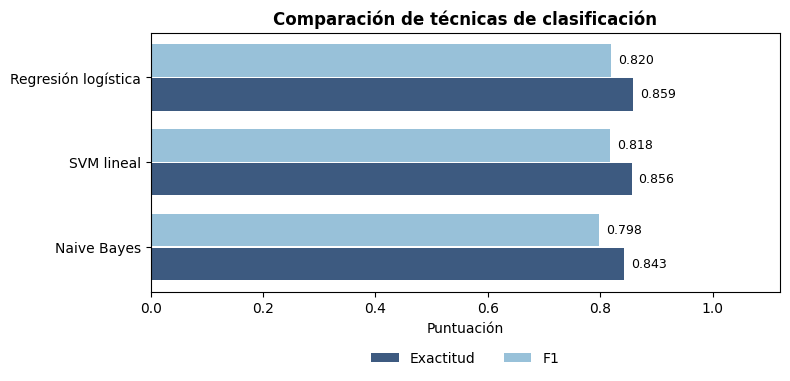

In [20]:
# Gráfico 4: comparación visual de modelos
fig, ax = plt.subplots(figsize=(8, 4))
orden = comparativa.sort_values("F1")
y_pos = np.arange(len(orden))

b1 = ax.barh(y_pos - 0.2, orden["Exactitud"], height=0.38, label="Exactitud", color="#3d5a80")
b2 = ax.barh(y_pos + 0.2, orden["F1"],        height=0.38, label="F1",        color="#98c1d9")

for barras in (b1, b2):
  for barra in barras:
    ancho = barra.get_width()
    ax.text(ancho+0.012, barra.get_y() + barra.get_height()/2,
            f"{ancho:.3f}", va="center", fontsize=9)
ax.set_yticks(y_pos)
ax.set_yticklabels(orden["Modelo"])
ax.set_xlim(0, 1.12)
ax.set_xlabel("Puntuación")
ax.set_title("Comparación de técnicas de clasificación", weight="bold")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=2, frameon=False)
plt.tight_layout()
plt.show()

8. Mejora del modelo

In [21]:
# Mejora 1: representación TF-IDF más rica
vec_mejorado = TfidfVectorizer(
    max_features=50_000,    # 5 veces más vocabulario que el modelo base
    ngram_range=(1, 3),     # hasta trigramas: capta "no lo recomiendo"
    min_df=3,               # algo más permisivo para no perder expresiones poco frecuentes
    sublinear_tf=True,      # escala logarítmica: repetir 10 veces no vale 10 veces más
    stop_words=STOPWORDS_ES
)

Xtr_mej = vec_mejorado.fit_transform(X_train)
Xte_mej = vec_mejorado.transform(X_test)

print(f"Vocabulario del modelo base    : {len(vec_base.get_feature_names_out()):,} términos")
print(f"Vocabulario del modelo mejorado: {len(vec_mejorado.get_feature_names_out()):,} términos")

Vocabulario del modelo base    : 10,000 términos
Vocabulario del modelo mejorado: 50,000 términos


In [22]:
# Mejoras 2 y 3: equilibrio de clases + búsqueda de hiperparámetros
from sklearn.model_selection import GridSearchCV

# La búsqueda prueba todas las combinaciones y se queda con la mejor.La hacemos sobre una MUESTRA de 60.000 reseñas;
# después reentrenamos el modelo ganador con TODOS los datos.
muestra = np.random.RandomState(SEMILLA).choice(Xtr_mej.shape[0],
                                                size=min(60_000, Xtr_mej.shape[0]),
                                                replace=False)

parametros = {
    "C": [0.5, 1, 4, 10],                 # fuerza de la regularización
    "class_weight": [None, "balanced"],   # con y sin equilibrio de clases
}

busqueda = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=SEMILLA),
    parametros,
    cv=3,               # 3 particiones internas para evaluar cada combinación
    scoring="f1",       # optimizamos F1 (equilibra precisión y cobertura)
    n_jobs=-1,          # usa todos los núcleos del procesador
    verbose=1
)
busqueda.fit(Xtr_mej[muestra], y_train.iloc[muestra])

print(f"\nMejores parámetros encontrados: {busqueda.best_params_}")
print(f"Mejor F1 durante la búsqueda   : {busqueda.best_score_:.4f}")

Fitting 3 folds for each of 8 candidates, totalling 24 fits

Mejores parámetros encontrados: {'C': 1, 'class_weight': 'balanced'}
Mejor F1 durante la búsqueda   : 0.8099


In [23]:
# Entrenamos el modelo final con los mejores parámetros y TODOS los datos
modelo_final = LogisticRegression(
    max_iter=1000,
    random_state=SEMILLA,
    **busqueda.best_params_    # aplica automáticamente C y class_weight ganadores
)
modelo_final.fit(Xtr_mej, y_train)

pred_final = modelo_final.predict(Xte_mej)
acc_final = accuracy_score(y_test, pred_final)
f1_final  = f1_score(y_test, pred_final)

# Comparamos contra la línea de referencia para cuantificar la mejora
print(f"MODELO BASE    → Exactitud: {acc_base:.4f} | F1: {f1_base:.4f}")
print(f"MODELO MEJORADO→ Exactitud: {acc_final:.4f} | F1: {f1_final:.4f}")
print(f"\nMejora en exactitud: {(acc_final - acc_base) * 100:+.2f} puntos porcentuales")
print(f"Mejora en F1       : {(f1_final - f1_base) * 100:+.2f} puntos porcentuales")

MODELO BASE    → Exactitud: 0.8587 | F1: 0.8197
MODELO MEJORADO→ Exactitud: 0.8614 | F1: 0.8321

Mejora en exactitud: +0.28 puntos porcentuales
Mejora en F1       : +1.24 puntos porcentuales


In [24]:
# Mejora 4: validación cruzada (¿el resultado es estable?)
from sklearn.model_selection import cross_val_score

# Entrena y evalúa 5 veces con particiones distintas de los datos.
# Si las 5 puntuaciones son parecidas, el modelo es ESTABLE y no fue suerte.
puntuaciones = cross_val_score(
    LogisticRegression(max_iter=1000, random_state=SEMILLA, **busqueda.best_params_),
    Xtr_mej, y_train,
    cv=5, scoring="f1", n_jobs=-1
)

print("F1 en cada una de las 5 particiones:", np.round(puntuaciones, 4))
print(f"\nF1 medio          : {puntuaciones.mean():.4f}")
print(f"Desviación típica : {puntuaciones.std():.4f}")
print("\nUna desviación baja (< 0.01) indica que el modelo es estable y")
print("los resultados no dependen de cómo se dividan los datos.")

F1 en cada una de las 5 particiones: [0.8272 0.8287 0.8287 0.8295 0.829 ]

F1 medio          : 0.8286
Desviación típica : 0.0008

Una desviación baja (< 0.01) indica que el modelo es estable y
los resultados no dependen de cómo se dividan los datos.


9. Evaluación del modelo final

INFORME DE CLASIFICACIÓN DEL MODELO FINAL
               precision    recall  f1-score   support

No satisfecho      0.902     0.863     0.882     24000
   Satisfecho      0.807     0.859     0.832     16000

     accuracy                          0.861     40000
    macro avg      0.854     0.861     0.857     40000
 weighted avg      0.864     0.861     0.862     40000



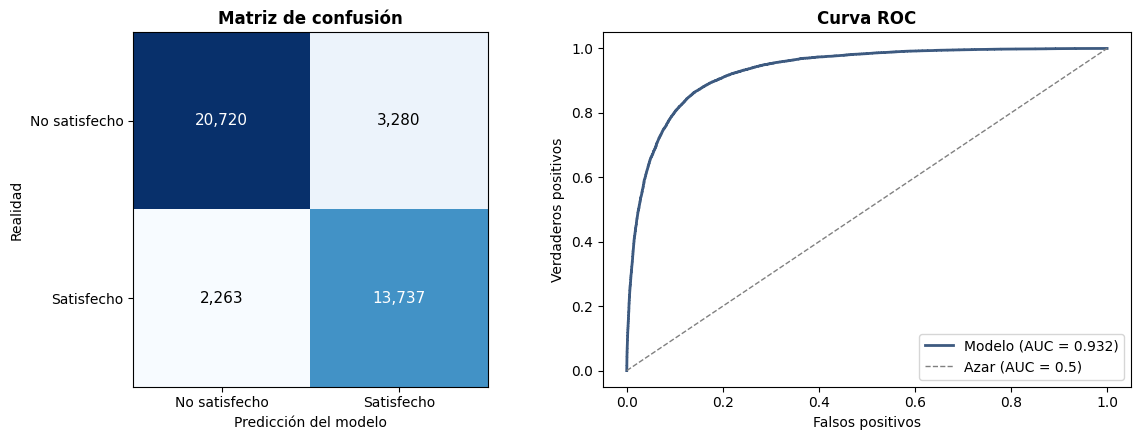

AUC = 0.932  (1.0 sería perfecto; 0.5 sería azar)


In [25]:
# Informe de clasificación y matriz de confusión
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score

print("INFORME DE CLASIFICACIÓN DEL MODELO FINAL")
print(classification_report(y_test, pred_final,
                            target_names=["No satisfecho", "Satisfecho"], digits=3))

cm = confusion_matrix(y_test, pred_final)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Matriz de confusión: dónde acierta y dónde se equivoca
ax = axes[0]
ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_xticklabels(["No satisfecho", "Satisfecho"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["No satisfecho", "Satisfecho"])
ax.set_xlabel("Predicción del modelo"); ax.set_ylabel("Realidad")
ax.set_title("Matriz de confusión", weight="bold")
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=11)

# Curva ROC: capacidad de separar las dos clases
ax = axes[1]
probabilidades = modelo_final.predict_proba(Xte_mej)[:, 1]
fpr, tpr, _ = roc_curve(y_test, probabilidades)
auc = roc_auc_score(y_test, probabilidades)
ax.plot(fpr, tpr, color="#3d5a80", lw=2, label=f"Modelo (AUC = {auc:.3f})")
ax.plot([0, 1], [0, 1], "--", color="gray", lw=1, label="Azar (AUC = 0.5)")
ax.set_xlabel("Falsos positivos"); ax.set_ylabel("Verdaderos positivos")
ax.set_title("Curva ROC", weight="bold"); ax.legend(loc="lower right")

plt.tight_layout()
plt.show()

print(f"AUC = {auc:.3f}  (1.0 sería perfecto; 0.5 sería azar)")

10. Interpretabilidad del modelo

In [26]:
# Palabras más determinantes según el modelo
terminos = np.array(vec_mejorado.get_feature_names_out())
coeficientes = modelo_final.coef_[0]

orden = np.argsort(coeficientes)
top_negativas = terminos[orden[:15]]      # coeficientes más negativos → descontento
top_positivas = terminos[orden[-15:]][::-1]  # más positivos → satisfacción

print("TÉRMINOS QUE MÁS EMPUJAN HACIA 'CLIENTE SATISFECHO':")
print("  " + ", ".join(top_positivas))
print("\nTÉRMINOS QUE MÁS EMPUJAN HACIA 'CLIENTE DESCONTENTO':")
print("  " + ", ".join(top_negativas))

TÉRMINOS QUE MÁS EMPUJAN HACIA 'CLIENTE SATISFECHO':
  perfecto, genial, perfectamente, excelente, buen, perfecta, encanta, encantado, buena, encantada, contenta, ideal, fenomenal, contento, recomendable

TÉRMINOS QUE MÁS EMPUJAN HACIA 'CLIENTE DESCONTENTO':
  mala, decepción, mal, regular, decepcionado, decepcionante, decepcionada, devuelto, roto, poca, fatal, nada, demasiado, devolví, devolución


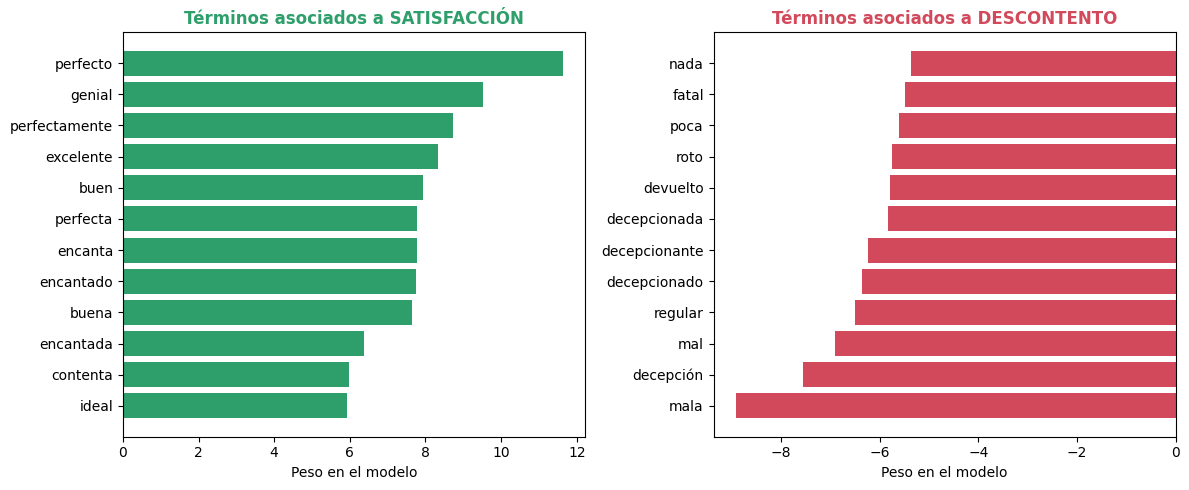

In [27]:
# Gráfico 5: visualización de los términos más influyentes
n = 12
idx_pos = orden[-n:]
idx_neg = orden[:n]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].barh(terminos[idx_pos], coeficientes[idx_pos], color="#2e9e6b")
axes[0].set_title("Términos asociados a SATISFACCIÓN", weight="bold", color="#2e9e6b")
axes[0].set_xlabel("Peso en el modelo")

axes[1].barh(terminos[idx_neg], coeficientes[idx_neg], color="#d1495b")
axes[1].set_title("Términos asociados a DESCONTENTO", weight="bold", color="#d1495b")
axes[1].set_xlabel("Peso en el modelo")

plt.tight_layout()
plt.show()

In [28]:
# ── Ejemplo práctico: explicar una predicción concreta ───────────────────
def explicar(texto_resena, top=5, umbral=0.05):
    "Predice la satisfacción de una reseña y muestra qué términos pesaron."
    x = vec_mejorado.transform([texto_resena.lower()])
    probabilidad = modelo_final.predict_proba(x)[0, 1]

    # Contribución de cada término = su valor TF-IDF × su coeficiente
    contribucion = x.multiply(coeficientes).toarray()[0]
    ranking = contribucion.argsort()

    a_favor = [
        (terminos[i], contribucion[i])
        for i in ranking[::-1]
        if contribucion[i] > umbral][:top]

    en_contra = [
        (terminos[i], contribucion[i])
        for i in ranking
        if contribucion[i] < -umbral][:top]

    print(f'Reseña: "{texto_resena}"')
    print(f"  → Probabilidad de cliente satisfecho: {probabilidad:.1%}")
    print(
        "  → A favor  :",
        ", ".join(f"{t} ({c:+.2f})" for t, c in a_favor) or "—")
    print(
        "  → En contra:",
        ", ".join(f"{t} ({c:+.2f})" for t, c in en_contra) or "—")
    print()

explicar(
    "El producto llegó rápido y la calidad es excelente, muy contenta con la compra")

explicar(
    "Carísimo y encima llegó roto, la atención al cliente fue pésima")

Reseña: "El producto llegó rápido y la calidad es excelente, muy contenta con la compra"
  → Probabilidad de cliente satisfecho: 98.5%
  → A favor  : excelente (+1.92), contenta (+1.41), rápido (+0.67), compra (+0.47), llegó rápido (+0.37)
  → En contra: rápido calidad (-0.24), llegó (-0.22), producto (-0.21)

Reseña: "Carísimo y encima llegó roto, la atención al cliente fue pésima"
  → Probabilidad de cliente satisfecho: 0.9%
  → A favor  : atención (+0.45)
  → En contra: roto (-1.45), pésima (-1.32), carísimo (-0.55), cliente (-0.49), llegó (-0.25)



11. Guardar el modelo (productivización)

In [32]:
# Guardamos modelo y vectorizador
import joblib

CARPETA = "/content/drive/MyDrive/TFM"

joblib.dump(vec_mejorado, f"{CARPETA}/vectorizador.pkl")
joblib.dump(modelo_final, f"{CARPETA}/modelo.pkl")

# Guardamos también una ficha con la información del modelo (versionado):
# saber con qué datos y parámetros se entrenó es parte del gobierno del modelo.
ficha = {
    "fecha_entrenamiento": pd.Timestamp.now().strftime("%Y-%m-%d %H:%M"),
    "n_resenas_entrenamiento": int(len(X_train)),
    "parametros": {k: str(v) for k, v in busqueda.best_params_.items()},
    "exactitud_test": round(float(acc_final), 4),
    "f1_test": round(float(f1_final), 4),
    "auc_test": round(float(auc), 4),
    "n_terminos": int(len(terminos)),
}
with open(f"{CARPETA}/ficha_modelo.json", "w", encoding="utf-8") as f:
    json.dump(ficha, f, ensure_ascii=False, indent=2)

print("Archivos generados en", CARPETA)
print("  · modelo.pkl        → el modelo entrenado")
print("  · vectorizador.pkl  → el vocabulario TF-IDF")
print("  · ficha_modelo.json → metadatos del entrenamiento (versionado)")
print("\nFicha del modelo:")
print(json.dumps(ficha, ensure_ascii=False, indent=2))

Archivos generados en /content/drive/MyDrive/TFM
  · modelo.pkl        → el modelo entrenado
  · vectorizador.pkl  → el vocabulario TF-IDF
  · ficha_modelo.json → metadatos del entrenamiento (versionado)

Ficha del modelo:
{
  "fecha_entrenamiento": "2026-09-16 07:18",
  "n_resenas_entrenamiento": 160000,
  "parametros": {
    "C": "1",
    "class_weight": "balanced"
  },
  "exactitud_test": 0.8614,
  "f1_test": 0.8321,
  "auc_test": 0.9322,
  "n_terminos": 50000
}


In [30]:
# Exportamos una muestra en CSV para probar el dashboard
# El dashboard lee archivos CSV; esta muestra sirve para demostrarlo.
muestra_csv = df[["review_body", "stars", "product_category"]].sample(3000, random_state=SEMILLA)
muestra_csv.to_csv("/content/drive/MyDrive/TFM/muestra_resenas.csv", index=False, encoding="utf-8")
print("Guardado en /content/drive/MyDrive/TFM/muestra_resenas.csv")

Guardado en /content/drive/MyDrive/TFM/muestra_resenas.csv


Exportacion del modelo a formato web

In [38]:
# Extraemos el vocabulario, los pesos IDF y los coeficientes del modelo para que la herramienta pueda reproducir la predicción sin ejecutar Python.
import json, numpy as np

p = vec_mejorado.get_params()
print("PARÁMETROS DEL VECTORIZADOR")
for clave in ["lowercase", "strip_accents", "token_pattern", "ngram_range",
              "sublinear_tf", "norm", "stop_words", "min_df", "max_df",
              "max_features", "binary", "smooth_idf", "use_idf"]:
    print(f"  {clave:15s} = {p.get(clave)!r}")

print("\nn.º de términos :", len(vec_mejorado.vocabulary_))
print("intercepto      :", float(modelo_final.intercept_[0]))
print("clases          :", modelo_final.classes_)

# Muestra de control: 10 reseñas con su puntuación según el modelo en Python.
control = df["texto"].sample(10, random_state=SEMILLA).tolist()
valores = modelo_final.decision_function(vec_mejorado.transform(control))
print("\nMUESTRA DE CONTROL")
for t, v in zip(control, valores):
    print(f"  {v:+.6f}  |  {t[:70]}")

PARÁMETROS DEL VECTORIZADOR
  lowercase       = True
  strip_accents   = None
  token_pattern   = '(?u)\\b\\w\\w+\\b'
  ngram_range     = (1, 3)
  sublinear_tf    = True
  norm            = 'l2'
  stop_words      = ['de', 'la', 'el', 'que', 'y', 'en', 'los', 'un', 'una', 'por', 'con', 'para', 'es', 'me', 'no', 'lo', 'se', 'su', 'al', 'del', 'las', 'muy', 'mas', 'más', 'pero', 'como', 'le', 'ya', 'o', 'he', 'ha', 'este', 'esta', 'son', 'fue', 'tiene', 'hay', 'porque', 'cuando']
  min_df          = 3
  max_df          = 1.0
  max_features    = 50000
  binary          = False
  smooth_idf      = True
  use_idf         = True

n.º de términos : 50000
intercepto      : -0.7462255797052779
clases          : [0 1]

MUESTRA DE CONTROL
  -0.880256  |  el drone funciona a la perfeccion mini usb cable de carga defectuoso p
  -0.977724  |  muy largo el cable es muy largo y es comodo pero me duró poco tiempo p
  +3.887039  |  práctico ideal para mis necesidades.
  -3.558299  |  cómo en aliexpress, 

In [39]:

import json, numpy as np

CARPETA = "/content/drive/MyDrive/TFM"

# Vocabulario ordenado por el índice interno del vectorizador
terminos = [None] * len(vec_mejorado.vocabulary_)
for termino, indice in vec_mejorado.vocabulary_.items():
    terminos[indice] = termino

# Muestra de control: reseñas con la puntuación que les da el modelo AQUÍ.
# La página web deberá reproducir estos mismos valores. Es la prueba de que
# la herramienta usa el modelo entrenado y no una aproximación.
control_textos = df["texto"].sample(12, random_state=SEMILLA).tolist()
control_valores = modelo_final.decision_function(
    vec_mejorado.transform(control_textos)
)

modelo_web = {
    "version": pd.Timestamp.now().strftime("%Y-%m-%d %H:%M"),
    "terminos": terminos,
    "idf": [round(float(v), 8) for v in vec_mejorado.idf_],
    "coef": [round(float(v), 8) for v in modelo_final.coef_[0]],
    "intercepto": float(modelo_final.intercept_[0]),
    "stop_words": list(vec_mejorado.get_params()["stop_words"]),
    "metricas": {
        "exactitud": round(float(acc_final), 4),
        "f1": round(float(f1_final), 4),
        "auc": round(float(auc), 4),
        "n_entrenamiento": int(len(X_train)),
    },
    "control": [
        {"texto": t, "valor": round(float(v), 6)}
        for t, v in zip(control_textos, control_valores)
    ],
}

ruta = f"{CARPETA}/modelo_web.json"
with open(ruta, "w", encoding="utf-8") as f:
    json.dump(modelo_web, f, ensure_ascii=False, separators=(",", ":"))

import os
print(f"Guardado: {ruta}")
print(f"Tamaño  : {os.path.getsize(ruta)/1024/1024:.2f} MB")
print(f"Términos: {len(terminos):,}")
print(f"Control : {len(modelo_web['control'])} reseñas de verificación")

Guardado: /content/drive/MyDrive/TFM/modelo_web.json
Tamaño  : 1.80 MB
Términos: 50,000
Control : 12 reseñas de verificación


In [40]:
# Otra muestra para probar la herramienta, esta vez de una sola industria
muestra_libros = df[df["product_category"] == "book"][["review_body", "stars", "product_category"]]
muestra_libros.sample(2000, random_state=SEMILLA).to_csv(
    f"{CARPETA}/muestra_libros.csv", index=False, encoding="utf-8")
print("Guardado:", len(muestra_libros), "reseñas disponibles de esa categoría")

Guardado: 5264 reseñas disponibles de esa categoría


# Herramienta en línea
https://judigcs.github.io/tfm-satisfaccion-cliente/herramienta.html

In [ ]:
!jupyter nbconvert --to html --embed-images "/content/drive/MyDrive/TFM/TFM_Judith_Garcia.ipynb" --output-dir "/content/drive/MyDrive/TFM"